## Step 1: Load and Preview the Dataset

We begin by importing necessary libraries and loading the dataset from the data folder.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Aviation_Data.csv', low_memory=False)

df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [ ]:
df.shape

(90348, 31)

In [ ]:
df.columns          # Column names (Index object)

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [ ]:
df.index            # Row indices

RangeIndex(start=0, stop=90348, step=1)

In [ ]:
df.dtypes              # Data type of each column

,0
Event.Id,object
Investigation.Type,object
Accident.Number,object
Event.Date,object
Location,object
Country,object
Latitude,object
Longitude,object
Airport.Code,object
Airport.Name,object


In [ ]:
df.info()              # Non-null counts and types

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90348 entries, 0 to 90347
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      90348 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [ ]:
df.isnull().sum()                     # Nulls per column

,0
Event.Id,1459
Investigation.Type,0
Accident.Number,1459
Event.Date,1459
Location,1511
Country,1685
Latitude,55966
Longitude,55975
Airport.Code,40216
Airport.Name,37644


In [ ]:
df[df.isnull().any(axis=1)]          # Rows with any nulls

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90343,20221227106491,Accident,ERA23LA093,2022-12-26,"Annapolis, MD",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,0.0,1.0,0.0,0.0,NaN,NaN,NaN,29-12-2022
90344,20221227106494,Accident,ERA23LA095,2022-12-26,"Hampton, NH",United States,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
90345,20221227106497,Accident,WPR23LA075,2022-12-26,"Payson, AZ",United States,341525N,1112021W,PAN,PAYSON,...,Personal,NaN,0.0,0.0,0.0,1.0,VMC,NaN,NaN,27-12-2022
90346,20221227106498,Accident,WPR23LA076,2022-12-26,"Morgan, UT",United States,NaN,NaN,NaN,NaN,...,Personal,MC CESSNA 210N LLC,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [ ]:
display(df.describe(include='all').transpose())
print("\nData Types:\n", df.dtypes)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Event.Id,88889,87951,20001214X45071,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Investigation.Type,90348,71,Accident,85015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Accident.Number,88889,88863,WPR23LA045,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Event.Date,88889,14782,1982-05-16,25,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location,88837,27758,"ANCHORAGE, AK",434,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,88663,219,United States,82248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Latitude,34382,25589,332739N,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Longitude,34373,27154,0112457W,24,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Code,50132,10374,NONE,1488,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Airport.Name,52704,24870,Private,240,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Data Types:
 Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object


In [ ]:
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
numeric_cols = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Step 2: Data Cleaning

Here, we handle missing values, convert column data types, and remove irrelevant or duplicate entries.


In [ ]:
#Handle missing data
df.dropna(subset=['Event.Date'], inplace=True)
df.fillna(0, inplace=True)

In [ ]:
#Handling missing values
print("Missing values:\n", df[numeric_cols].isnull().sum())
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

Missing values:
 Total.Fatal.Injuries      0
Total.Serious.Injuries    0
Total.Minor.Injuries      0
Total.Uninjured           0
dtype: int64


In [ ]:
# STEP 4: Outlier removal (IQR method)
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= Q1 - 1.5 * IQR) & (df[column] <= Q3 + 1.5 * IQR)]

for col in numeric_cols:
    df = remove_outliers(df, col)

In [ ]:
df.duplicated().value_counts()

,count
False,42242


In [ ]:
df = df.drop_duplicates()
df.shape

(42242, 31)

## Step 3: Exploratory Data Analysis (EDA)

Explore accident distribution by year, aircraft type, and injury severity.


In [ ]:
# Ensure Event.Date is in datetime format
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')

In [ ]:
# Drop rows where date is missing
df = df.dropna(subset=['Event.Date'])

In [ ]:
# Extract year from Event.Date
df['event_year'] = df['Event.Date'].dt.year

In [ ]:
# Yearly accident counts
accident_by_year = df['event_year'].value_counts().sort_index()


## Step 4: Visualizations

Use visual tools to understand high-risk aircraft types and patterns in accident causes or severity.


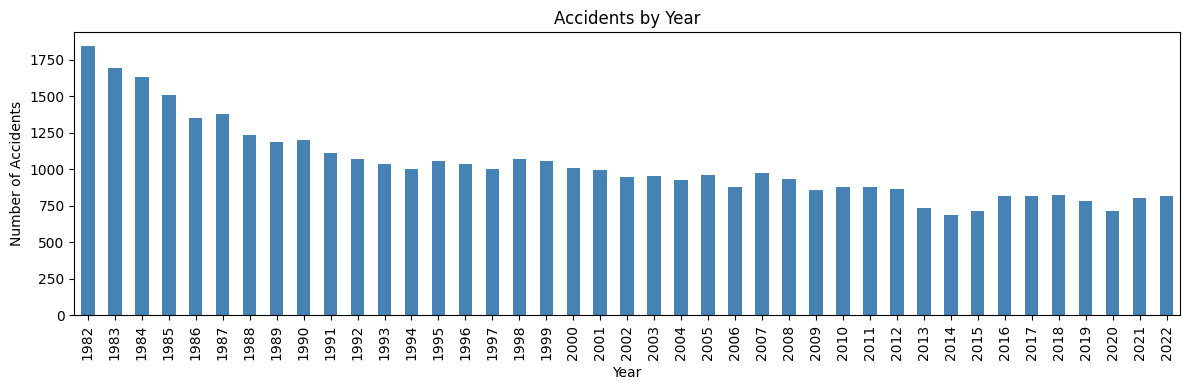

In [ ]:
# Plot yearly accidents
plt.figure(figsize=(12, 4))
accident_by_year.plot(kind='bar', color='steelblue')
plt.title('Accidents by Year')
plt.xlabel('Year')
plt.ylabel('Number of Accidents')
plt.tight_layout()
plt.show()


In [ ]:
# Top 10 aircraft makes by count
top_makes = df['Make'].value_counts().head(10)
print("Top 10 Aircraft Makes:\n", top_makes)

Top 10 Aircraft Makes:
 Make
Cessna      12087
Piper        5864
CESSNA       2680
Beech        1808
PIPER        1488
Bell          863
Grumman       684
BOEING        569
Robinson      503
Mooney        445
Name: count, dtype: int64


/tmp/ipython-input-2326762197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='Blues_r')


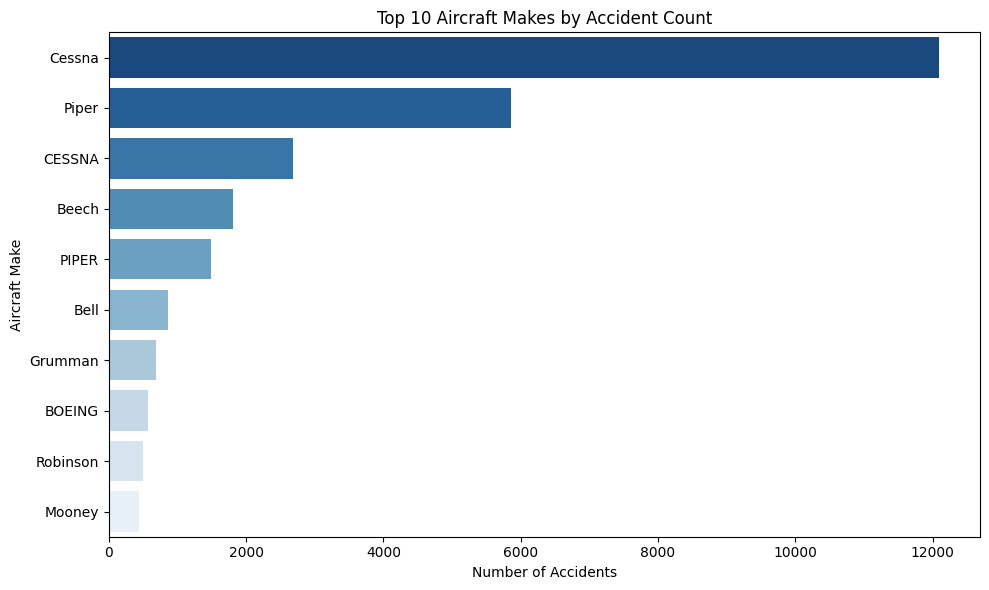

In [ ]:
# Aircraft Make vs. Accident Count
# Ensure 'Make' column exists and clean
if 'Make' in df.columns:
    df['Make'] = df['Make'].fillna('Unknown')

    # Get top 10 aircraft makes
    top_aircraft = df['Make'].value_counts().head(10)

    # Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_aircraft.values, y=top_aircraft.index, palette='Blues_r')
    plt.title("Top 10 Aircraft Makes by Accident Count")
    plt.xlabel("Number of Accidents")
    plt.ylabel("Aircraft Make")
    plt.tight_layout()
    plt.show()
else:
    print("Column 'Make' not found in the dataset.")


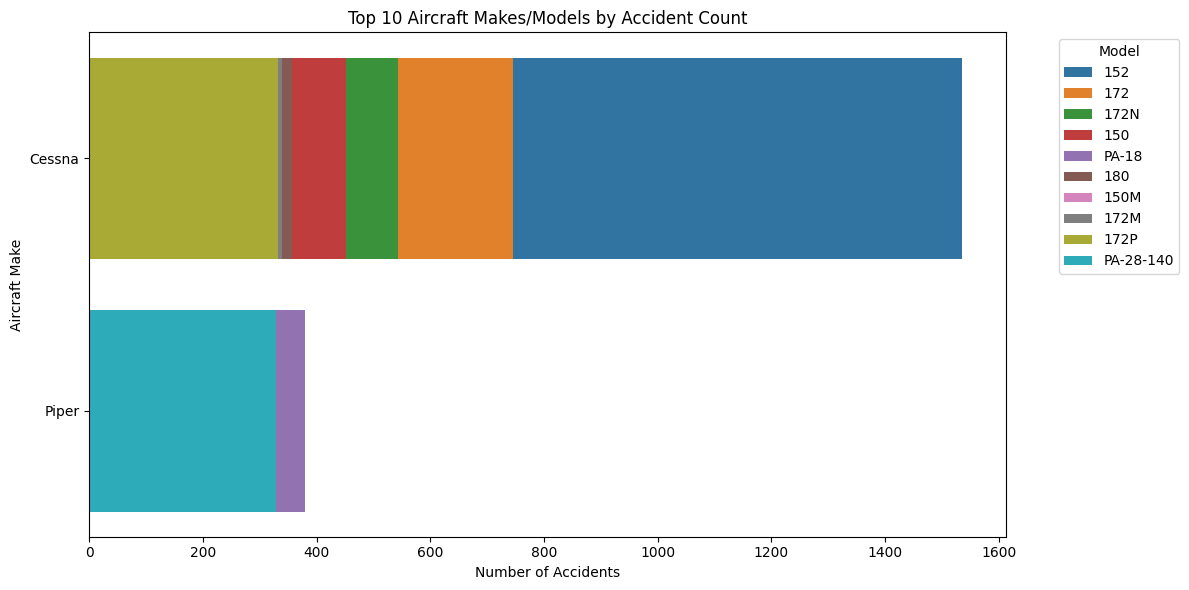

In [ ]:
# Group by aircraft Make and Model
accident_freq = df.groupby(['Make', 'Model']).size().reset_index(name='Accident.Count')

# Top 10 aircraft types by accident count
top_aircraft_accidents = accident_freq.sort_values(by='Accident.Count', ascending=False).head(10)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=top_aircraft_accidents, x='Accident.Count', y='Make', hue='Model', dodge=False)
plt.title('Top 10 Aircraft Makes/Models by Accident Count')
plt.xlabel('Number of Accidents')
plt.ylabel('Aircraft Make')
plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()